<a href="https://colab.research.google.com/github/muhammadbilal1010/Flappy-Bird-Game/blob/main/WIND_POWER_FORECASTING(PROTOTYPE)_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Wind Power Forecasting Using AI/ML — Prototype

Developed a prototype for my Final Year Project, **“Wind Power Forecasting Using AI/ML,”** to explore the application of machine learning for predicting wind power generation.

Using a publicly available **Kaggle wind power dataset**, I performed data preprocessing and prepared the dataset for machine learning. I then trained and evaluated two supervised learning models:

* **Random Forest Regressor**
* **XGBoost Regressor**

The models were used to learn the relationship between the available wind-related features and power generation and to generate wind power predictions. I compared the model performance using appropriate regression evaluation metrics and visualized the predicted and actual power output.

This prototype provided a foundation for the main FYP, where I plan to further explore **AI/ML-based wind power forecasting**, improve the forecasting approach, and investigate its potential application in **sustainable and renewable energy systems**.

**Technologies:** Python, Pandas, Random Forest, XGBoost, Machine Learning, Data Analysis


Mount Google Drive (to save data & models):

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Download Dataset

In [ ]:
import kagglehub
import os

# Download latest version
file_path = kagglehub.dataset_download("theforcecoder/wind-power-forecasting")

print("Path to dataset directory:", file_path)
print(os.listdir(file_path))

100%|██████████| 7.51M/7.51M [00:00<00:00, 64.9MB/s]

Extracting files...


Path to dataset directory: /root/.cache/kagglehub/datasets/theforcecoder/wind-power-forecasting/versions/2
['Turbine_Data.csv']


**Import Libraries**

In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing
import xgboost as xgb
import seaborn as sns
import matplotlib.pyplot as plt

**Load CSV Dataset nto a Pandas Dataframe**

In [ ]:
data = pd.read_csv(
    file_path + "/Turbine_Data.csv",
    parse_dates=['Unnamed: 0'],
    index_col='Unnamed: 0'
)
data.index = pd.to_datetime(data.index)


In [ ]:
data.head()

,ActivePower,AmbientTemperatue,BearingShaftTemperature,Blade1PitchAngle,Blade2PitchAngle,Blade3PitchAngle,ControlBoxTemperature,GearboxBearingTemperature,GearboxOilTemperature,GeneratorRPM,...,GeneratorWinding2Temperature,HubTemperature,MainBoxTemperature,NacellePosition,ReactivePower,RotorRPM,TurbineStatus,WTG,WindDirection,WindSpeed
2017-12-31 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,G01,NaN,NaN
2017-12-31 00:10:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,G01,NaN,NaN
2017-12-31 00:20:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,G01,NaN,NaN
2017-12-31 00:30:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,G01,NaN,NaN
2017-12-31 00:40:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,G01,NaN,NaN


In [ ]:
data.shape

(118224, 21)

In [ ]:
data.drop_duplicates(inplace=True)

In [ ]:
data.shape

(95185, 21)

In [ ]:
data.head()

,ActivePower,AmbientTemperatue,BearingShaftTemperature,Blade1PitchAngle,Blade2PitchAngle,Blade3PitchAngle,ControlBoxTemperature,GearboxBearingTemperature,GearboxOilTemperature,GeneratorRPM,...,GeneratorWinding2Temperature,HubTemperature,MainBoxTemperature,NacellePosition,ReactivePower,RotorRPM,TurbineStatus,WTG,WindDirection,WindSpeed
2017-12-31 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,G01,NaN,NaN
2018-01-01 00:00:00+00:00,-5.357727,23.148729,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,8.000000,-9.960830,NaN,NaN,G01,8.000000,2.279088
2018-01-01 00:10:00+00:00,-5.822360,23.039754,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,300.428571,-9.628441,NaN,NaN,G01,300.428571,2.339343
2018-01-01 00:20:00+00:00,-5.279409,22.948703,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,340.000000,-9.491235,NaN,NaN,G01,340.000000,2.455610
2018-01-01 00:30:00+00:00,-4.648054,22.966851,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,345.000000,-9.856136,NaN,NaN,G01,345.000000,2.026754


In [ ]:
data.nunique()

,0
ActivePower,94084
AmbientTemperatue,93678
BearingShaftTemperature,62286
Blade1PitchAngle,38946
Blade2PitchAngle,39021
Blade3PitchAngle,39021
ControlBoxTemperature,1
GearboxBearingTemperature,62313
GearboxOilTemperature,62412
GeneratorRPM,61074


In [ ]:
data.drop(['WTG', 'ControlBoxTemperature'],axis=1,inplace=True)

In [ ]:
data.shape

(95185, 19)

In [ ]:
data = data[data['ActivePower']>=0]

In [ ]:
data.isna().sum()

,0
ActivePower,0
AmbientTemperatue,1032
BearingShaftTemperature,26821
Blade1PitchAngle,43282
Blade2PitchAngle,43365
Blade3PitchAngle,43365
GearboxBearingTemperature,26819
GearboxOilTemperature,26806
GeneratorRPM,26810
GeneratorWinding1Temperature,26792


In [ ]:
data.describe()

,ActivePower,AmbientTemperatue,BearingShaftTemperature,Blade1PitchAngle,Blade2PitchAngle,Blade3PitchAngle,GearboxBearingTemperature,GearboxOilTemperature,GeneratorRPM,GeneratorWinding1Temperature,GeneratorWinding2Temperature,HubTemperature,MainBoxTemperature,NacellePosition,ReactivePower,RotorRPM,TurbineStatus,WindDirection,WindSpeed
count,78989.000000,77957.000000,52168.000000,35707.000000,35624.000000,35624.000000,52170.000000,52183.000000,52179.000000,52197.000000,52204.000000,52059.000000,52148.000000,58560.000000,78947.000000,52173.000000,5.252300e+04,58560.000000,78681.000000
mean,742.779831,28.443080,43.885682,3.002703,3.462299,3.462299,66.805007,58.915467,1285.209153,76.622661,75.965815,37.241433,39.300644,196.945957,107.690786,11.531054,2.564949e+03,196.945957,6.508584
std,595.334913,4.119607,4.989832,10.981182,10.882891,10.882891,8.809819,5.736098,336.558561,22.092388,22.149700,4.726533,5.303889,88.256950,118.044136,3.004769,3.924549e+05,88.256950,2.380567
min,0.000000,0.000000,0.000000,-1.960466,-2.406213,-2.406213,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-203.182591,0.000000,0.000000e+00,0.000000,0.000000
25%,225.562517,25.473630,40.575654,-0.979453,-0.473327,-0.473327,61.629546,55.577620,1030.767510,59.694965,58.885719,33.996185,35.556255,148.000000,0.587574,9.245588,2.000000e+00,148.000000,4.694561
50%,555.505381,28.049530,43.831462,-0.197471,0.295915,0.295915,66.542548,58.134012,1231.126300,69.688523,68.941923,37.022819,39.262500,181.666667,63.088679,11.041127,2.000000e+00,181.666667,6.104735
75%,1269.581314,31.231477,47.813746,2.170674,2.601339,2.601339,72.759474,62.503315,1592.696747,92.631987,92.135842,40.917918,42.960085,273.517857,180.786697,14.281437,2.000000e+00,273.517857,7.938625
max,1779.032433,41.809714,55.088655,89.027520,88.915344,88.915344,82.237932,70.764581,1809.941700,126.773031,126.043018,47.996185,53.768750,357.000000,403.713620,16.273495,6.574653e+07,357.000000,22.970893


**Data Visualization**

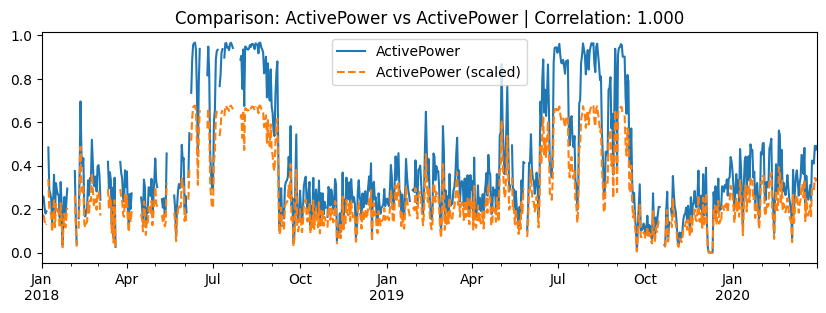

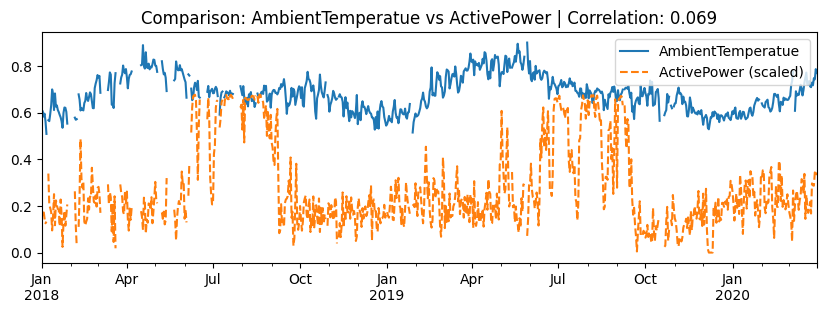

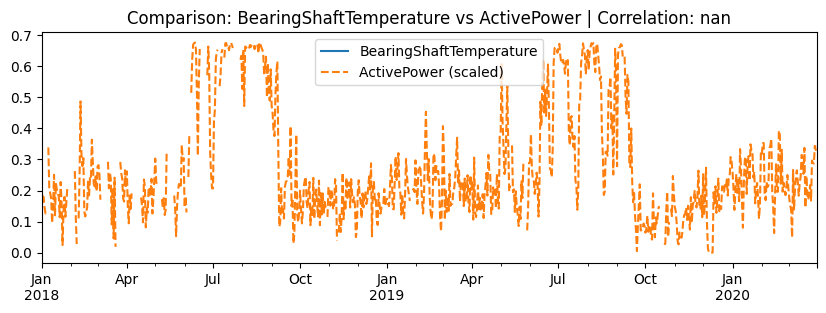

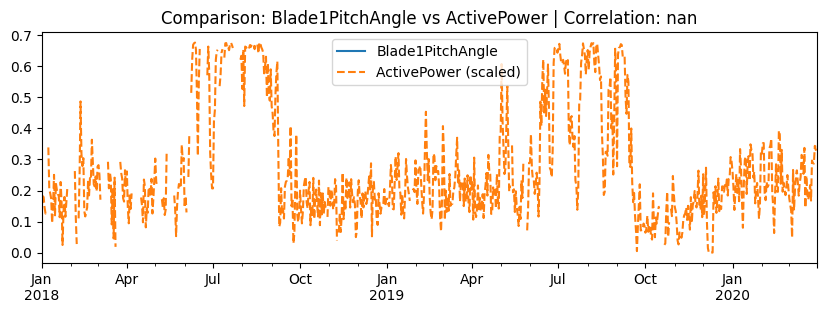

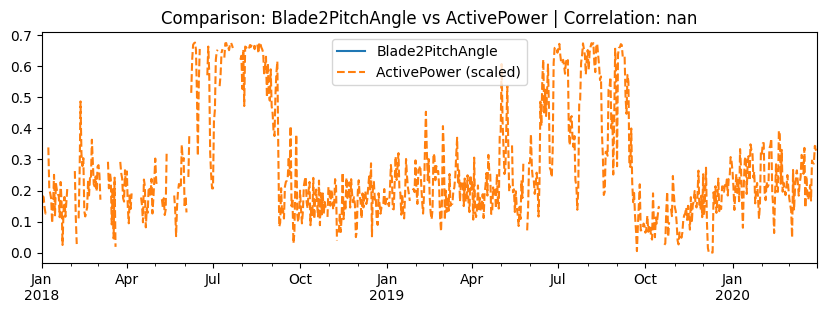

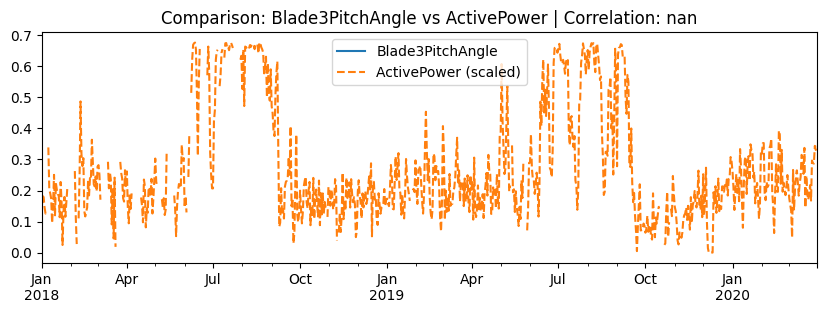

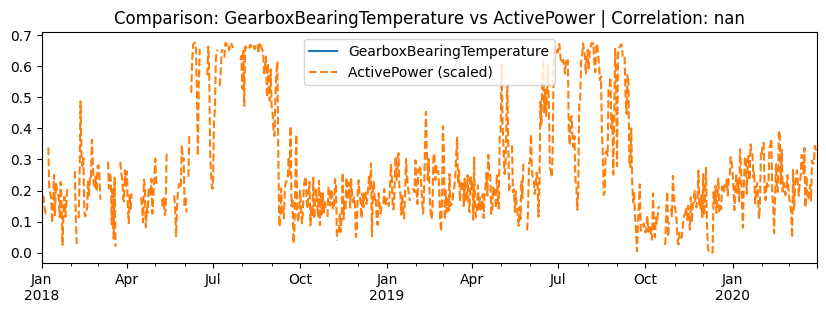

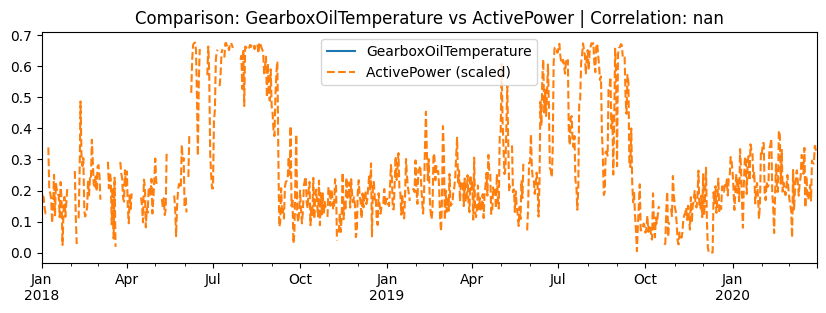

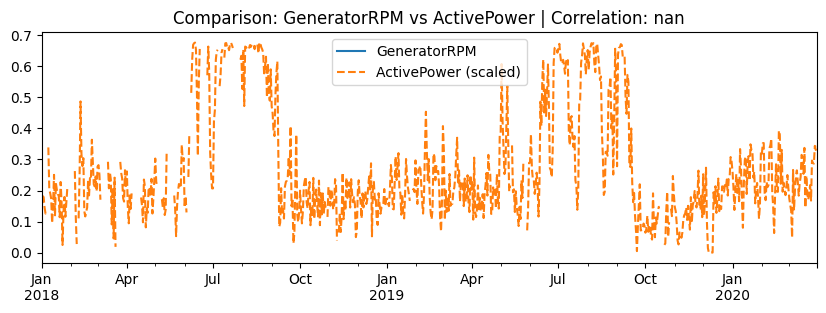

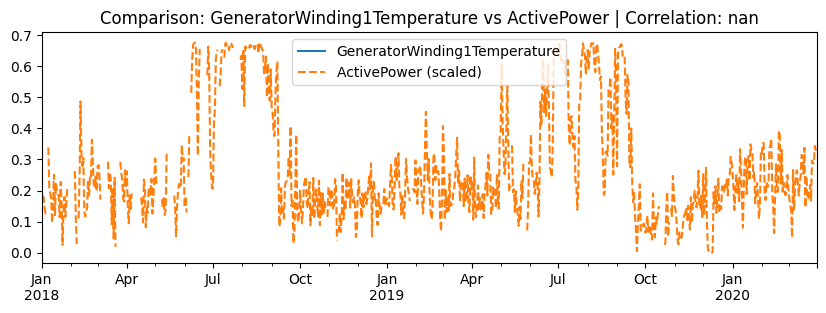

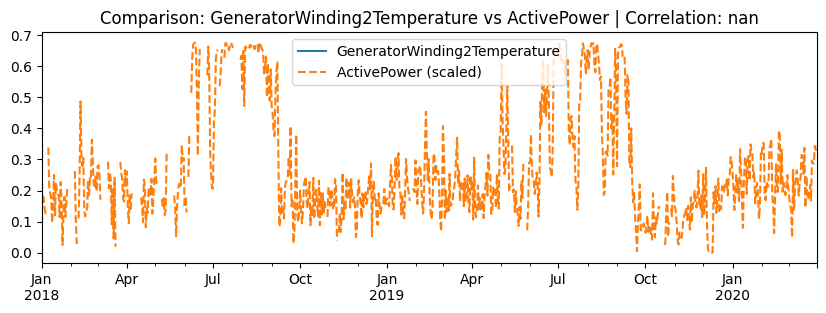

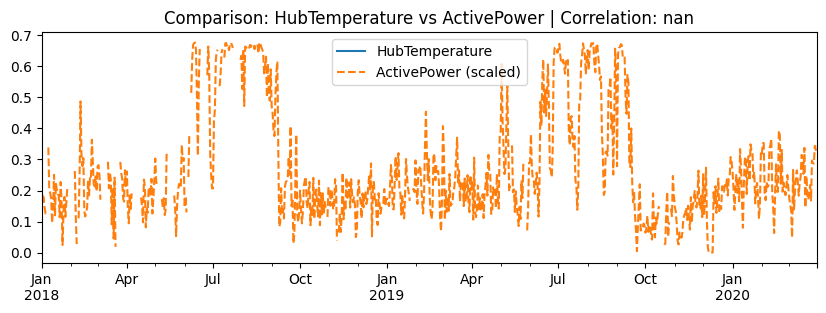

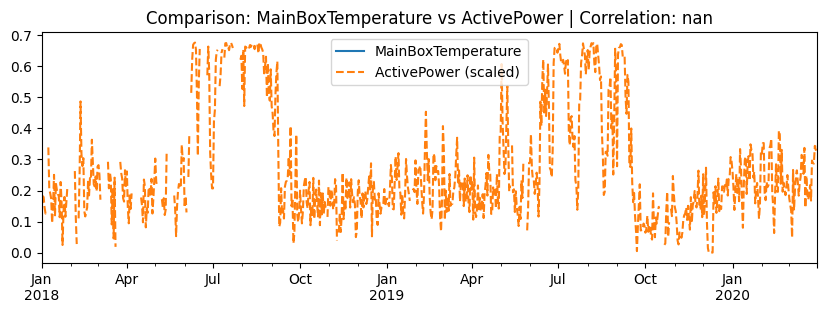

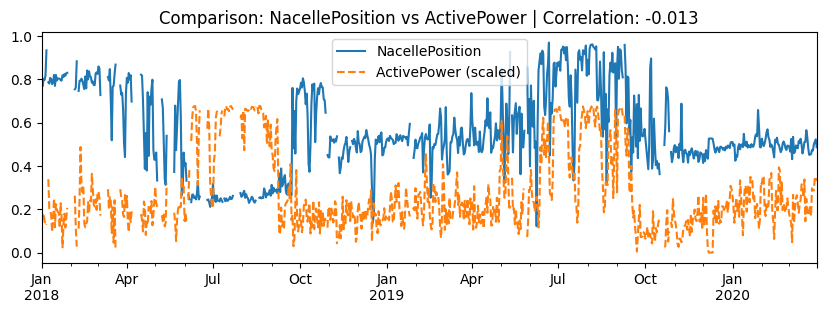

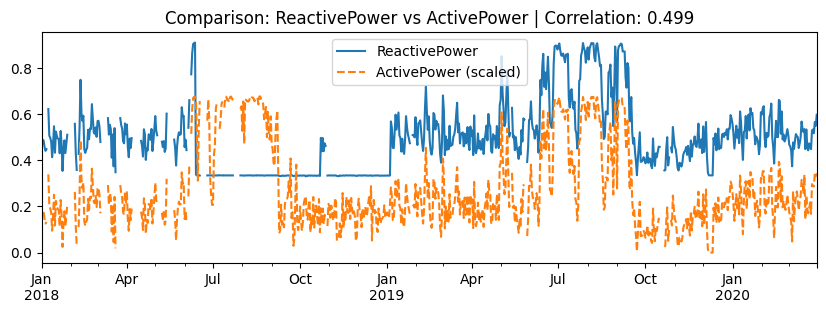

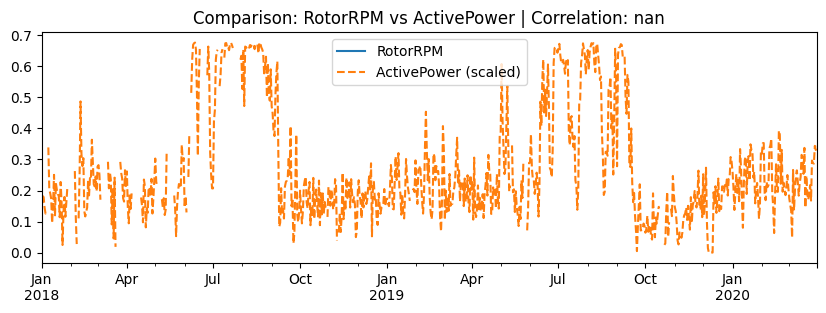

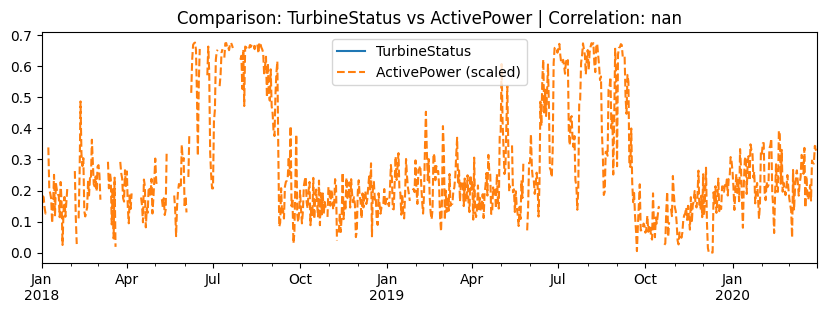

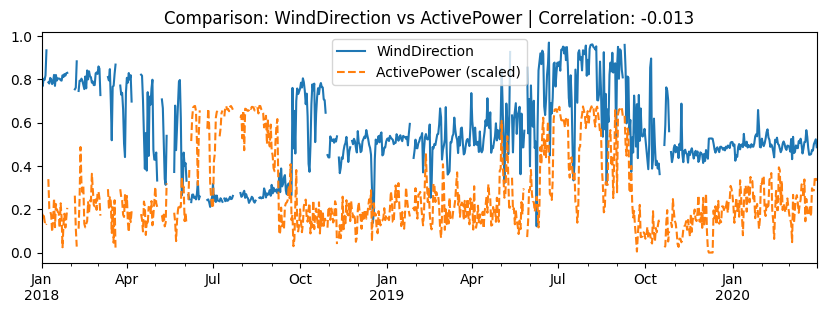

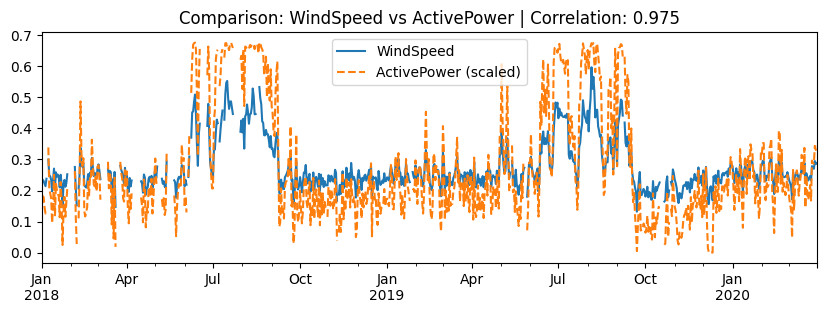

In [ ]:
d2 = data.copy()
for i in data:
    # 1. Scale the data (Min-Max)
    mini = min(d2[i])
    maxi = max(d2[i])
    d2[i] = (d2[i] - mini) / (maxi - mini)

    # 2. Resample for the plot
    resampled_i = d2[i].resample('D').mean()
    resampled_ap = (d2['ActivePower'] * 0.7).resample('D').mean()

    # 3. Calculate Correlation Coefficient (r)
    # This measures the linear relationship between the two resampled lines
    correlation = resampled_i.corr(resampled_ap)

    # 4. Plotting
    plt.figure(figsize=(10, 3))
    resampled_i.plot(legend=True, label=f'{i}')
    resampled_ap.plot(style='--', legend=True, label='ActivePower (scaled)')

    # Add correlation to the title (rounded to 3 decimal places)
    plt.title(f"Comparison: {i} vs ActivePower | Correlation: {correlation:.3f}")

    plt.legend() # Fixed: added parentheses
    plt.show()

--- Monthly Correlation Analysis ---
Variable: ActivePower               | Monthly Corr with ActivePower: 1.0000


/tmp/ipykernel_7239/3221454712.py:19: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_i = d2[i].resample('M').mean()
/tmp/ipykernel_7239/3221454712.py:20: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_ap = (d2['ActivePower'] * 0.7).resample('M').mean()


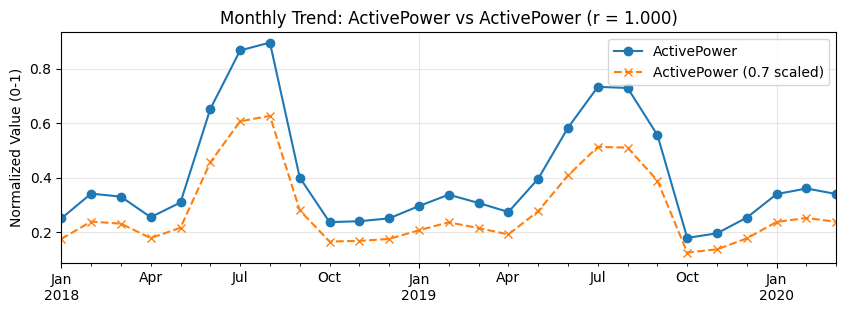

/tmp/ipykernel_7239/3221454712.py:19: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_i = d2[i].resample('M').mean()
/tmp/ipykernel_7239/3221454712.py:20: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_ap = (d2['ActivePower'] * 0.7).resample('M').mean()


Variable: AmbientTemperatue         | Monthly Corr with ActivePower: 0.1342


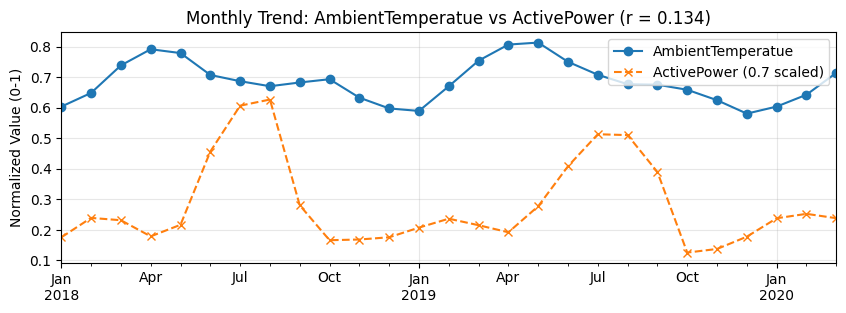

/tmp/ipykernel_7239/3221454712.py:19: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_i = d2[i].resample('M').mean()
/tmp/ipykernel_7239/3221454712.py:20: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_ap = (d2['ActivePower'] * 0.7).resample('M').mean()


Variable: BearingShaftTemperature   | Monthly Corr with ActivePower: 0.7264


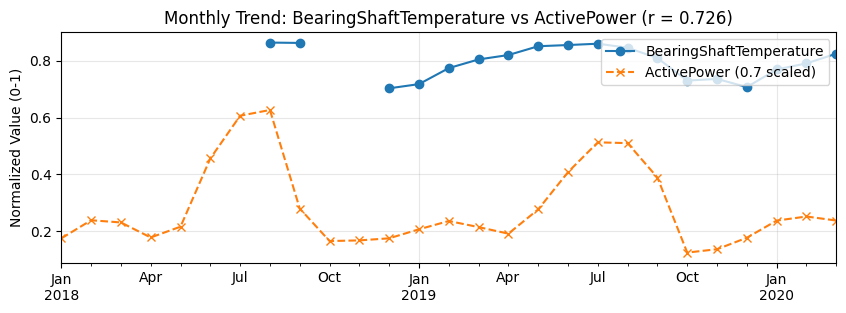

/tmp/ipykernel_7239/3221454712.py:19: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_i = d2[i].resample('M').mean()
/tmp/ipykernel_7239/3221454712.py:20: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_ap = (d2['ActivePower'] * 0.7).resample('M').mean()


Variable: Blade1PitchAngle          | Monthly Corr with ActivePower: 0.0582


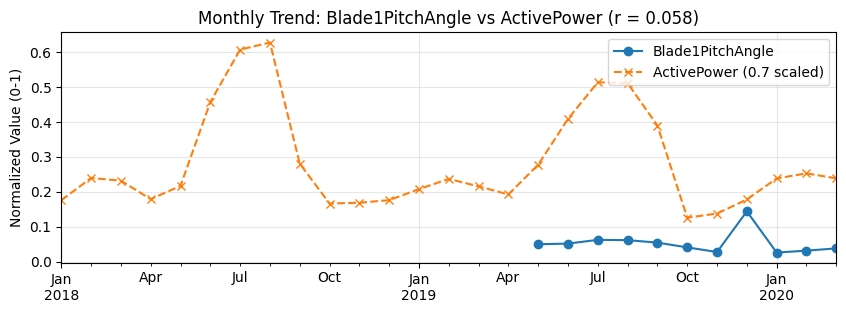

/tmp/ipykernel_7239/3221454712.py:19: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_i = d2[i].resample('M').mean()
/tmp/ipykernel_7239/3221454712.py:20: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_ap = (d2['ActivePower'] * 0.7).resample('M').mean()


Variable: Blade2PitchAngle          | Monthly Corr with ActivePower: 0.0565


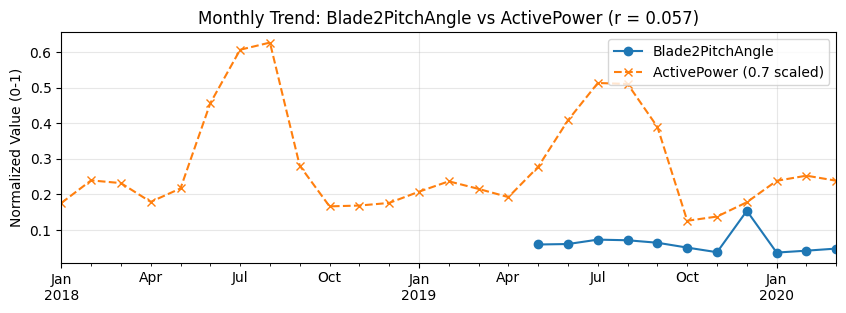

Variable: Blade3PitchAngle          | Monthly Corr with ActivePower: 0.0565


/tmp/ipykernel_7239/3221454712.py:19: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_i = d2[i].resample('M').mean()
/tmp/ipykernel_7239/3221454712.py:20: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_ap = (d2['ActivePower'] * 0.7).resample('M').mean()


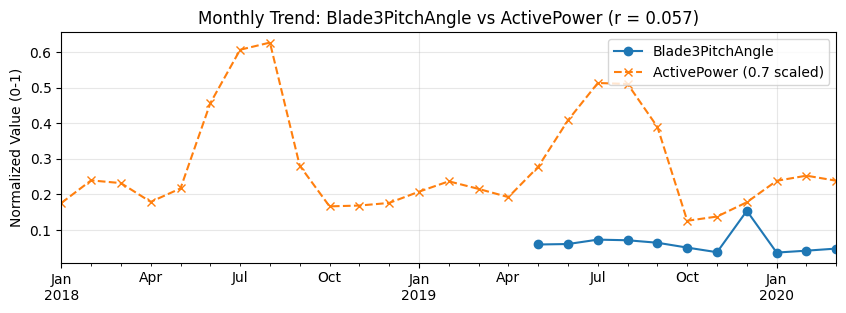

/tmp/ipykernel_7239/3221454712.py:19: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_i = d2[i].resample('M').mean()
/tmp/ipykernel_7239/3221454712.py:20: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_ap = (d2['ActivePower'] * 0.7).resample('M').mean()


Variable: GearboxBearingTemperature | Monthly Corr with ActivePower: 0.9186


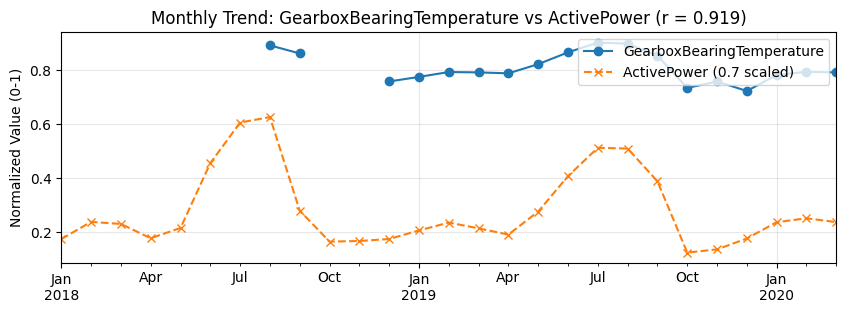

Variable: GearboxOilTemperature     | Monthly Corr with ActivePower: 0.8592


/tmp/ipykernel_7239/3221454712.py:19: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_i = d2[i].resample('M').mean()
/tmp/ipykernel_7239/3221454712.py:20: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_ap = (d2['ActivePower'] * 0.7).resample('M').mean()


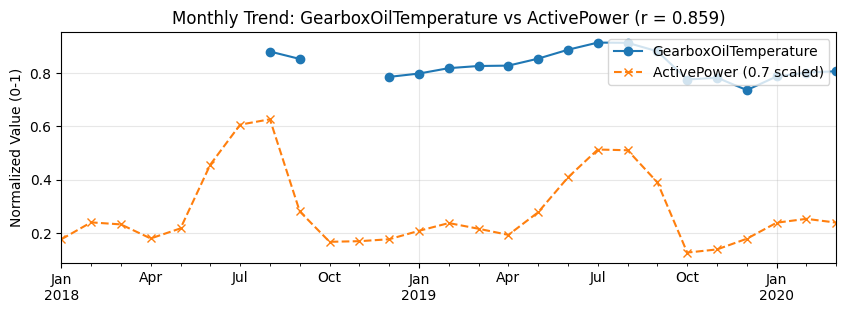

/tmp/ipykernel_7239/3221454712.py:19: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_i = d2[i].resample('M').mean()
/tmp/ipykernel_7239/3221454712.py:20: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_ap = (d2['ActivePower'] * 0.7).resample('M').mean()


Variable: GeneratorRPM              | Monthly Corr with ActivePower: 0.9468


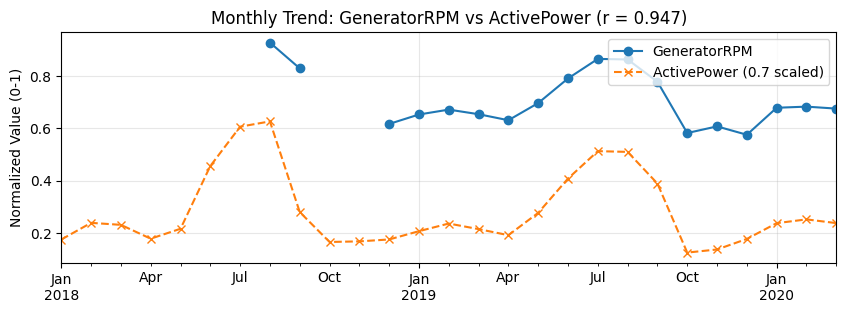

/tmp/ipykernel_7239/3221454712.py:19: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_i = d2[i].resample('M').mean()
/tmp/ipykernel_7239/3221454712.py:20: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_ap = (d2['ActivePower'] * 0.7).resample('M').mean()


Variable: GeneratorWinding1Temperature | Monthly Corr with ActivePower: 0.9588


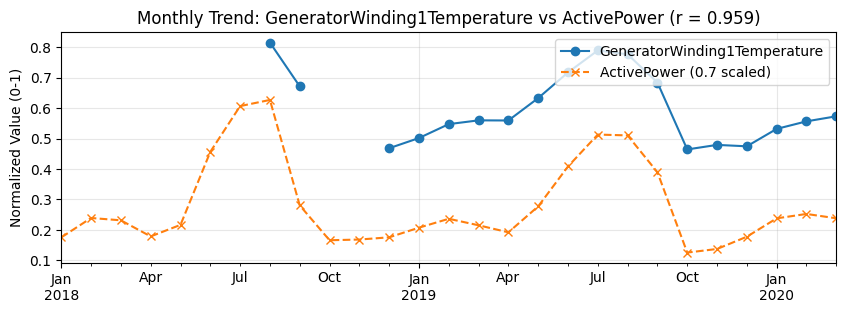

/tmp/ipykernel_7239/3221454712.py:19: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_i = d2[i].resample('M').mean()
/tmp/ipykernel_7239/3221454712.py:20: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_ap = (d2['ActivePower'] * 0.7).resample('M').mean()


Variable: GeneratorWinding2Temperature | Monthly Corr with ActivePower: 0.9587


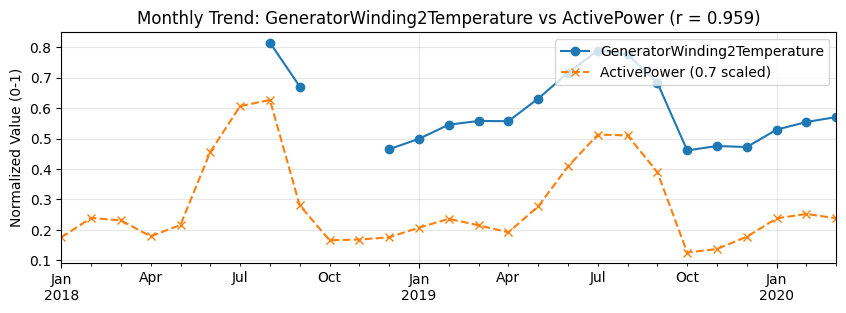

/tmp/ipykernel_7239/3221454712.py:19: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_i = d2[i].resample('M').mean()
/tmp/ipykernel_7239/3221454712.py:20: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_ap = (d2['ActivePower'] * 0.7).resample('M').mean()


Variable: HubTemperature            | Monthly Corr with ActivePower: 0.4533


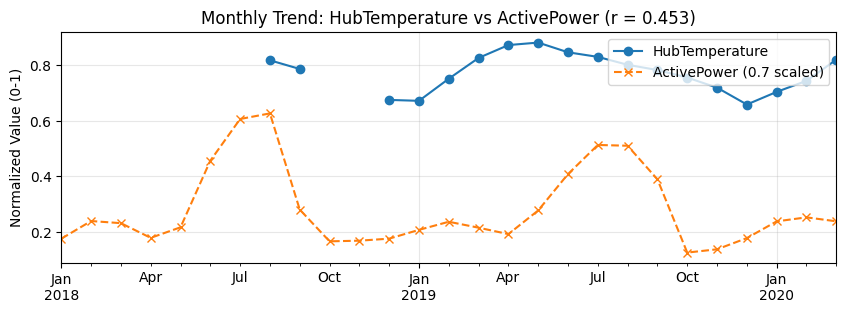

/tmp/ipykernel_7239/3221454712.py:19: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_i = d2[i].resample('M').mean()
/tmp/ipykernel_7239/3221454712.py:20: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_ap = (d2['ActivePower'] * 0.7).resample('M').mean()


Variable: MainBoxTemperature        | Monthly Corr with ActivePower: 0.4046


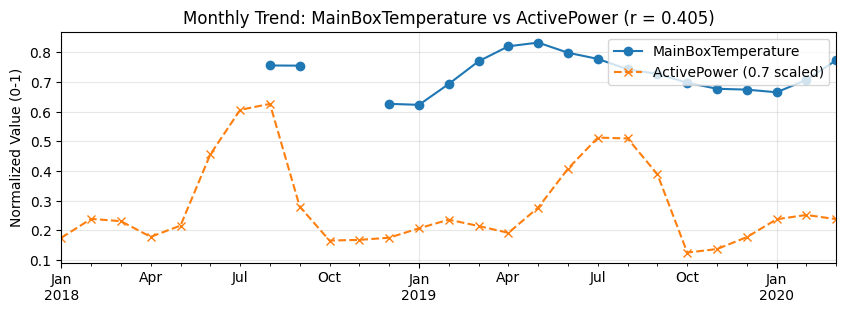

/tmp/ipykernel_7239/3221454712.py:19: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_i = d2[i].resample('M').mean()
/tmp/ipykernel_7239/3221454712.py:20: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_ap = (d2['ActivePower'] * 0.7).resample('M').mean()


Variable: NacellePosition           | Monthly Corr with ActivePower: -0.1730


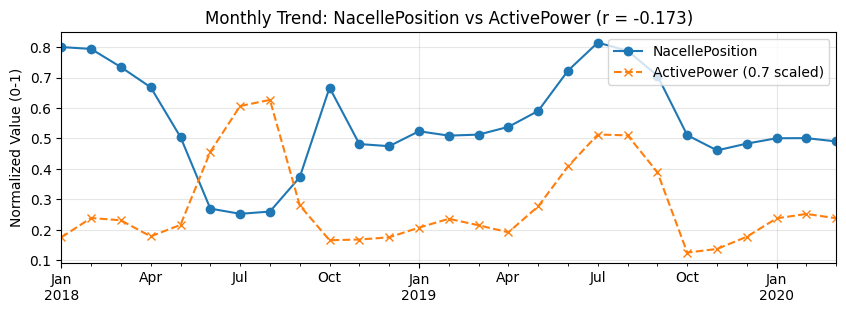

/tmp/ipykernel_7239/3221454712.py:19: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_i = d2[i].resample('M').mean()
/tmp/ipykernel_7239/3221454712.py:20: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_ap = (d2['ActivePower'] * 0.7).resample('M').mean()


Variable: ReactivePower             | Monthly Corr with ActivePower: 0.2727


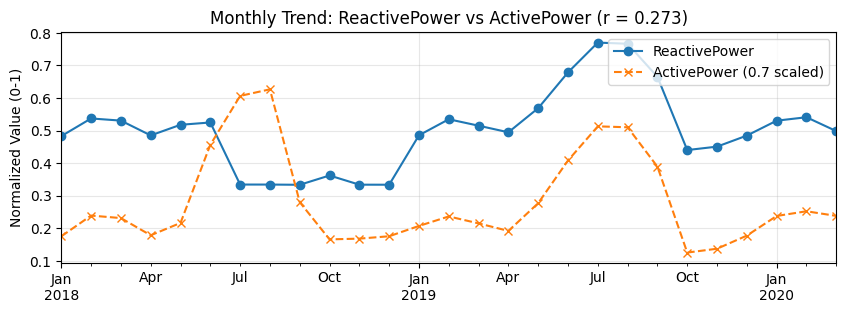

Variable: RotorRPM                  | Monthly Corr with ActivePower: 0.9472


/tmp/ipykernel_7239/3221454712.py:19: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_i = d2[i].resample('M').mean()
/tmp/ipykernel_7239/3221454712.py:20: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_ap = (d2['ActivePower'] * 0.7).resample('M').mean()


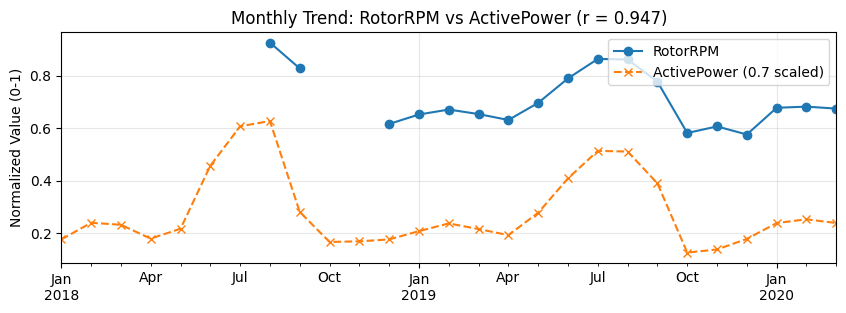

/tmp/ipykernel_7239/3221454712.py:19: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_i = d2[i].resample('M').mean()
/tmp/ipykernel_7239/3221454712.py:20: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_ap = (d2['ActivePower'] * 0.7).resample('M').mean()


Variable: TurbineStatus             | Monthly Corr with ActivePower: -0.2605


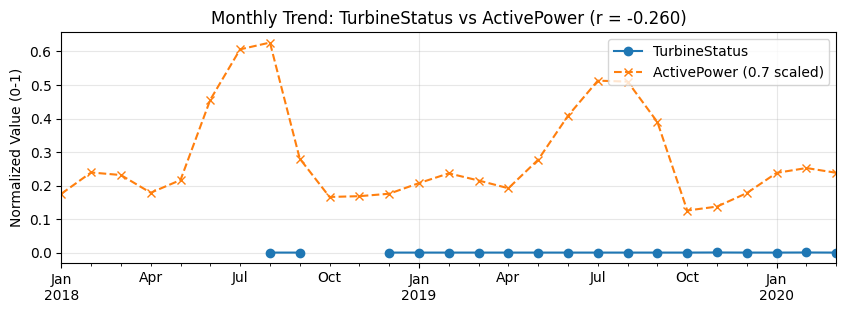

/tmp/ipykernel_7239/3221454712.py:19: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_i = d2[i].resample('M').mean()
/tmp/ipykernel_7239/3221454712.py:20: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_ap = (d2['ActivePower'] * 0.7).resample('M').mean()


Variable: WindDirection             | Monthly Corr with ActivePower: -0.1730


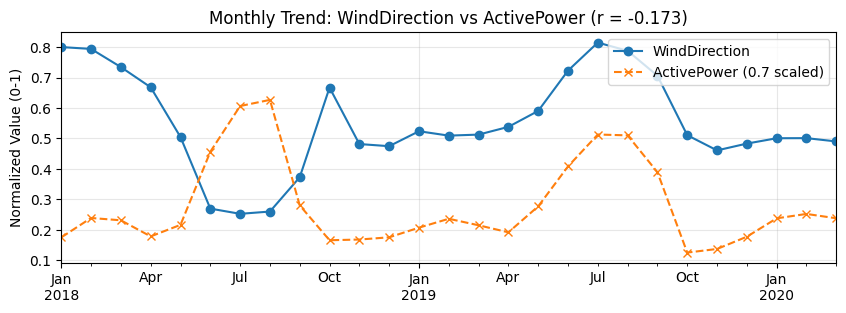

/tmp/ipykernel_7239/3221454712.py:19: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_i = d2[i].resample('M').mean()
/tmp/ipykernel_7239/3221454712.py:20: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_ap = (d2['ActivePower'] * 0.7).resample('M').mean()


Variable: WindSpeed                 | Monthly Corr with ActivePower: 0.9959


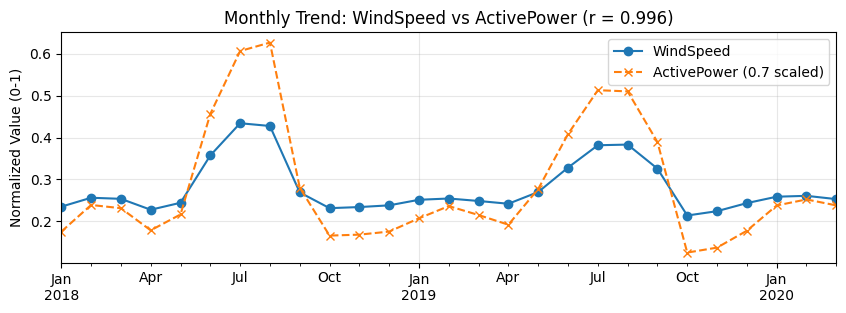

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Create a copy and normalize (Min-Max)
d2 = data.copy()
for i in d2.columns:
    mini = d2[i].min()
    maxi = d2[i].max()
    # Avoid division by zero for constant columns
    if maxi - mini != 0:
        d2[i] = (d2[i] - mini) / (maxi - mini)
    else:
        d2[i] = 0

print("--- Monthly Correlation Analysis ---")

for i in d2.columns:
    # 1. Resample to Monthly Mean (NaNs will remain where data is missing)
    monthly_i = d2[i].resample('M').mean()
    monthly_ap = (d2['ActivePower'] * 0.7).resample('M').mean()

    # 2. Calculate Correlation
    # (Note: .corr() internally skips NaN pairs but uses all other available data)
    correlation = monthly_i.corr(monthly_ap)

    # 3. Print the text value
    if not np.isnan(correlation):
        print(f"Variable: {i:<25} | Monthly Corr with ActivePower: {correlation:.4f}")
    else:
        print(f"Variable: {i:<25} | Monthly Corr with ActivePower: [NaN - Check for missing values]")

    # 4. Plotting
    plt.figure(figsize=(10, 3))

    # Plotting directly—NaNs will show as gaps in the line
    monthly_i.plot(label=f'{i}', legend=True, marker='o')
    monthly_ap.plot(style='--', label='ActivePower (0.7 scaled)', legend=True, marker='x')

    plt.title(f"Monthly Trend: {i} vs ActivePower (r = {correlation:.3f})")
    plt.ylabel("Normalized Value (0-1)")
    plt.grid(True, alpha=0.3)
    plt.legend(loc='upper right')
    plt.show()

<Axes: >

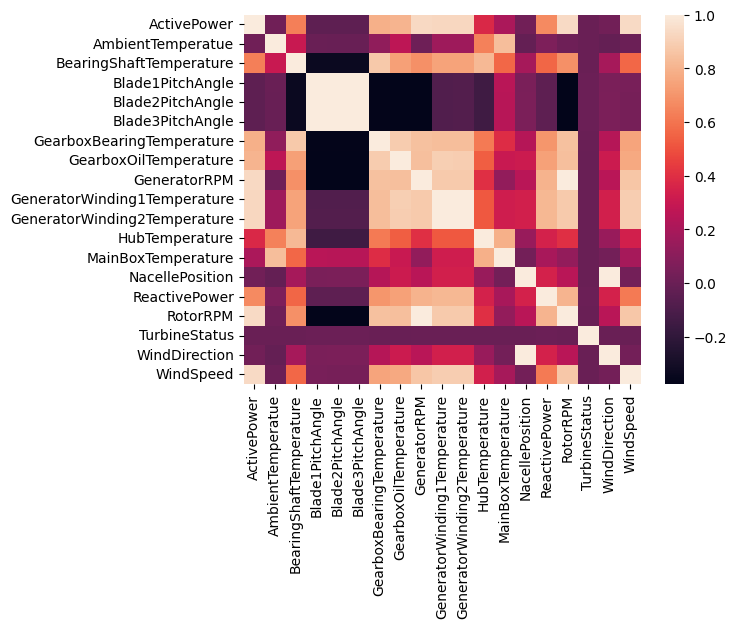

In [ ]:
sns.heatmap(data.corr())


In [ ]:
correlations = data.corr().unstack().sort_values(ascending=False)
correlations['ActivePower'].drop_duplicates()

,0
ActivePower,1.000000
WindSpeed,0.937870
RotorRPM,0.935928
GeneratorRPM,0.934303
GeneratorWinding2Temperature,0.928769
GeneratorWinding1Temperature,0.927517
GearboxOilTemperature,0.801319
GearboxBearingTemperature,0.786150
ReactivePower,0.662808
BearingShaftTemperature,0.631922


In [ ]:
# 1. Calculate correlations
corr_matrix = data.corr()
target_corr = corr_matrix['ActivePower'].abs()

# 2. Select features with correlation > 0.4 (excluding the target itself)
threshold = 0.4
high_corr_features = target_corr[target_corr > threshold].index.tolist()
high_corr_features.remove('ActivePower')

print(f"Selected Features: {high_corr_features}")

# 3. Update your training set
X = data[high_corr_features]
y = data['ActivePower']

# Split and train as you did before...

Selected Features: ['BearingShaftTemperature', 'GearboxBearingTemperature', 'GearboxOilTemperature', 'GeneratorRPM', 'GeneratorWinding1Temperature', 'GeneratorWinding2Temperature', 'ReactivePower', 'RotorRPM', 'WindSpeed']


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 1. Define features
features = [
    'BearingShaftTemperature', 'GearboxBearingTemperature',
    'GearboxOilTemperature', 'GeneratorRPM', 'GeneratorWinding1Temperature',
    'GeneratorWinding2Temperature', 'RotorRPM', 'WindSpeed'
]
target = 'ActivePower'

# 2. Cleanup & Diagnostic
# We filter to these features and drop NaNs
data_model = data[features + [target]].copy()
data_model = data_model.dropna()

print(f"Original data size: {len(data)}")
print(f"Cleaned data size (after dropping NaNs): {len(data_model)}")

if len(data_model) == 0:
    print("ERROR: All rows were dropped! One of your sensors might be entirely empty.")
else:
    # 3. Dynamic Time-Series Split (80% Train, 20% Test)
    split_idx = int(len(data_model) * 0.8)

    X = data_model[features]
    y = data_model[target]

    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

    print(f"Training on: {len(X_train)} samples")
    print(f"Testing on: {len(X_test)} samples")

    # 4. Train Random Forest
    print("Training Random Forest...")
    model_rf = RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
    model_rf.fit(X_train, y_train)

    # 5. Train XGBoost
    print("Training XGBoost...")
    model_xgb = xgb.XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6, random_state=42)
    model_xgb.fit(X_train, y_train)

    # 6. Generate Predictions
    pred_rf = model_rf.predict(X_test)
    pred_xgb = model_xgb.predict(X_test)

    # 7. Comparison Table
    def get_metrics(y_true, y_pred, name):
        return {
            'Model': name,
            'R2': r2_score(y_true, y_pred),
            'MAE': mean_absolute_error(y_true, y_pred),
            'RMSE': np.sqrt(mean_squared_error(y_true, y_pred))
        }

    results = pd.DataFrame([
        get_metrics(y_test, pred_rf, "Random Forest"),
        get_metrics(y_test, pred_xgb, "XGBoost")
    ])
    print("\n--- Model Comparison ---")
    print(results)

Original data size: 78989
Cleaned data size (after dropping NaNs): 51828
Training on: 41462 samples
Testing on: 10366 samples
Training Random Forest...
Training XGBoost...

--- Model Comparison ---
           Model        R2        MAE       RMSE
0  Random Forest  0.996747  19.841947  27.991127
1        XGBoost  0.996892  19.550609  27.358116



--- Feature Set Comparison ---
                 Feature Set  Count        R2        MAE       RMSE
0  Full (Kinetics + Thermal)      8  0.996892  19.550609  27.358116
1    Reduced (Kinetics Only)      3  0.996738  19.928955  28.031536


/tmp/ipykernel_7239/3407268359.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Feature Set', y='R2', data=results_comparison, palette='viridis')


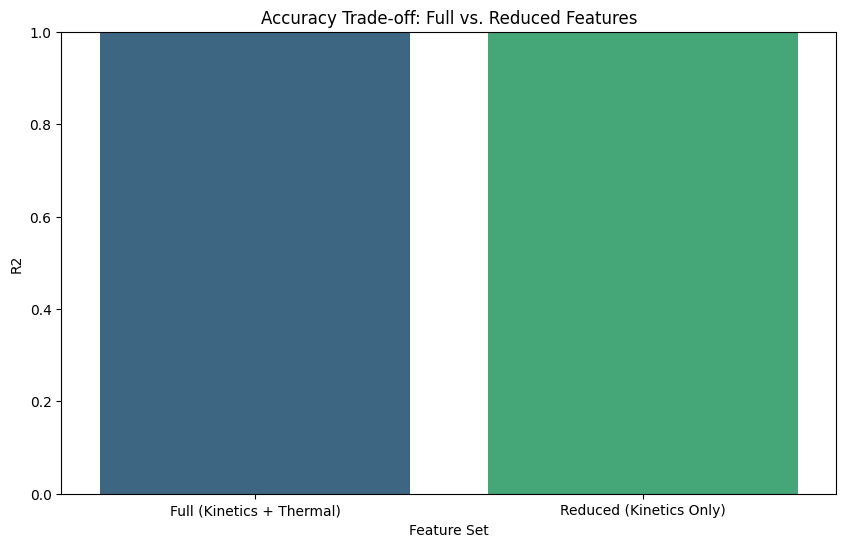

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 1. Define Feature Sets
full_features = [
    'BearingShaftTemperature', 'GearboxBearingTemperature',
    'GearboxOilTemperature', 'GeneratorRPM', 'GeneratorWinding1Temperature',
    'GeneratorWinding2Temperature', 'RotorRPM', 'WindSpeed'
]

# Focusing only on the kinetic drivers of power
reduced_features = ['WindSpeed', 'GeneratorRPM', 'RotorRPM']
target = 'ActivePower'

# 2. Cleanup
data_model = data[full_features + [target]].dropna()
split_idx = int(len(data_model) * 0.8)

def train_and_evaluate(feature_list, label):
    X = data_model[feature_list]
    y = data_model[target]

    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

    # Train XGBoost (usually faster and more accurate for this type of data)
    model = xgb.XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6, random_state=42)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    return {
        'Feature Set': label,
        'Count': len(feature_list),
        'R2': r2_score(y_test, preds),
        'MAE': mean_absolute_error(y_test, preds),
        'RMSE': np.sqrt(mean_squared_error(y_test, preds))
    }

# 3. Run Comparison
results_comparison = pd.DataFrame([
    train_and_evaluate(full_features, "Full (Kinetics + Thermal)"),
    train_and_evaluate(reduced_features, "Reduced (Kinetics Only)")
])

print("\n--- Feature Set Comparison ---")
print(results_comparison)

# 4. Visualize the Trade-off
plt.figure(figsize=(10, 6))
sns.barplot(x='Feature Set', y='R2', data=results_comparison, palette='viridis')
plt.title('Accuracy Trade-off: Full vs. Reduced Features')
plt.ylim(0, 1)
plt.show()


--- Feature Set Comparison ---
               Feature Set  Count        R2        MAE       RMSE
0        Full (8 Features)      8  0.996892  19.550609  27.358116
1     Reduced (3 Features)      3  0.996738  19.928955  28.031536
2  Single (WindSpeed Only)      1  0.976443  53.702577  75.324546


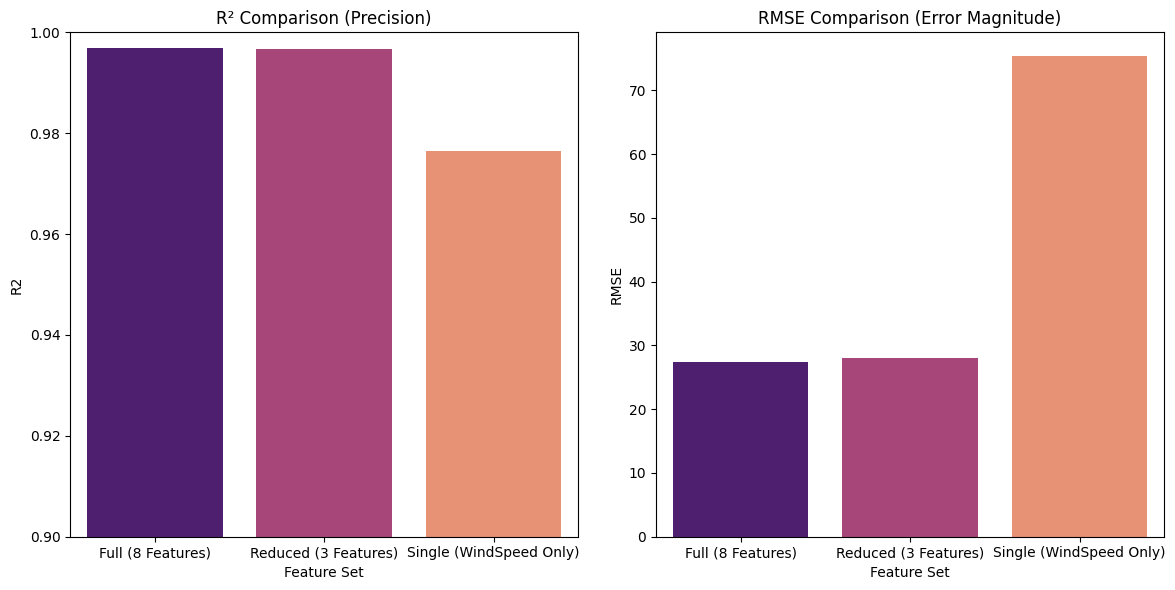

In [ ]:
# 1. Define the single most important feature
single_feature = ['WindSpeed']

# 2. Update your comparison list
results_comparison = pd.DataFrame([
    train_and_evaluate(full_features, "Full (8 Features)"),
    train_and_evaluate(reduced_features, "Reduced (3 Features)"),
    train_and_evaluate(single_feature, "Single (WindSpeed Only)")
])

# 3. Print the new comparison
print("\n--- Feature Set Comparison ---")
print(results_comparison.sort_values(by='R2', ascending=False))

# 4. Visualization
plt.figure(figsize=(12, 6))

# Subplot 1: Accuracy Comparison
plt.subplot(1, 2, 1)
sns.barplot(x='Feature Set', y='R2', data=results_comparison, hue='Feature Set', palette='magma', legend=False)
plt.title('R² Comparison (Precision)')
plt.ylim(0.9, 1.0) # Zoomed to see differences

# Subplot 2: Error Comparison (RMSE)
plt.subplot(1, 2, 2)
sns.barplot(x='Feature Set', y='RMSE', data=results_comparison, hue='Feature Set', palette='magma', legend=False)
plt.title('RMSE Comparison (Error Magnitude)')

plt.tight_layout()
plt.show()


--- Actual vs Predicted (3 Features) ---
        Actual   Predicted      Error
0   618.035872  582.956055  35.079817
1   485.559338  484.808868   0.750469
2   415.221839  427.268982 -12.047143
3   632.262170  591.554993  40.707177
4   553.574408  497.087341  56.487066
5   428.129167  435.946289  -7.817122
6   457.470445  428.427338  29.043107
7   595.498992  576.499695  18.999297
8   649.674129  592.065979  57.608150
9   628.255804  629.697815  -1.442011
10  705.671328  671.349487  34.321841
11  526.302612  541.857605 -15.554993
12  465.831507  462.958893   2.872614
13  515.541461  490.113586  25.427874
14  531.296253  503.871094  27.425160
15  546.343462  535.922180  10.421282
16  532.699956  539.829041  -7.129085
17  525.182265  499.227692  25.954573
18  575.086257  575.205994  -0.119737
19  869.367414  871.513672  -2.146258


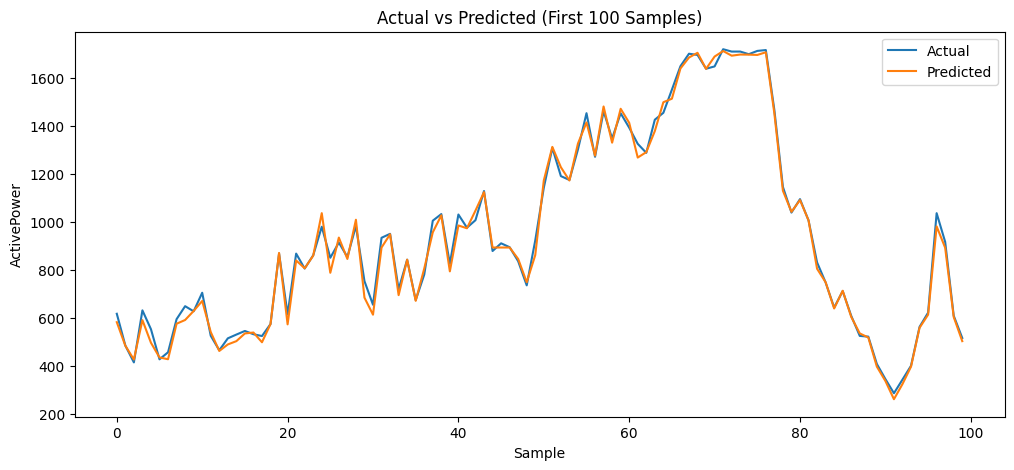

In [ ]:
++++++++++++++++++++++++++++++++# ============================================
# Actual vs Predicted VALUES
# For Reduced (3 Features) Model
# ============================================

# Prepare reduced feature dataset
X = data_model[reduced_features]
y = data_model[target]

# Train-test split
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Train model
model = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

model.fit(X_train, y_train)

# Predictions
preds = model.predict(X_test)

# ============================================
# Create Comparison Table
# ============================================

comparison_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': preds
})

# Optional: calculate error
comparison_df['Error'] = comparison_df['Actual'] - comparison_df['Predicted']

# Print first 20 rows
print("\n--- Actual vs Predicted (3 Features) ---")
print(comparison_df.head(20))

# ============================================
# Optional Plot
# ============================================

plt.figure(figsize=(12,5))

plt.plot(
    comparison_df['Actual'].values[:100],
    label='Actual'
)

plt.plot(
    comparison_df['Predicted'].values[:100],
    label='Predicted'
)

plt.title("Actual vs Predicted (First 100 Samples)")
plt.xlabel("Sample")
plt.ylabel("ActivePower")
plt.legend()

plt.show()